# v3qc-v2 — Truth-vs-estimated per-record AF, K_f-α sweep + filt2+rownorm (SEEDMIX_S1 Chr1)

**Updated 2026-05-18 with cn_var fix.** This rerun uses the corrected cn_var pipeline (cn_var_called mask, AC/AN-style projection that handles `./.` cells properly). Old (buggy, missing-as-REF) recipe also shown for diagnostic.

## Configs compared (all SEEDMIX_S1 Chr1 SNPs)

- **Recipe truth (fixed)**: `(h_uniform @ cn_var) / (h_uniform @ cn_var_called)` — the proper AC/AN projection.
- **Recipe truth (legacy)**: `h_uniform @ cn_var / 1` — the old missing-as-REF projection. Shown for comparison.
- **hapFIRE**: xwu's per-SNP AF (read-based, ground-truth-equivalent for pool composition).
- **cactus_em baseline**: no rownorm, fixed projection.
- **α = 0**: rownorm, no K_f post-correction.
- **α = 1**: rownorm + standard `h/K_f` mass-domain recovery.
- **α = 2, 3, 5**: stronger K_f penalties.
- **filt2 + rownorm**: drop ac<2 k-mer columns + row-norm.

All projection paths now divide by `(h @ cn_var_called)` (the called-mask renormalization).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.sparse import load_npz

ROOT = Path('/global/scratch/users/tbellg/kmate')
SCRATCH = ROOT / 'scratch'
HF_DIR = Path('/global/scratch/projects/fc_moilab/projects/grenenet-phase1/frequency/hapFIRE_frequencies/seed_mix')
CN_VAR_DIR = ROOT / 'poolfreq/data'

meta = np.load(CN_VAR_DIR / 'cn_var_231_v3qc_v2.meta.npz', allow_pickle=True)
rec_chrom = np.asarray(meta['chrom']).astype(str)
rec_pos   = np.asarray(meta['pos']).astype(np.int64)
rec_rlen  = np.asarray(meta['ref_len']).astype(np.int32)
rec_alen  = np.asarray(meta['alt_len']).astype(np.int32)
# Don't .astype(str) on ref/alt — some SV alleles are 100K+ bp so a fixed-width
# numpy string array would need 2.2 TB. Keep as object arrays.
rec_ref   = np.asarray(meta['ref'], dtype=object) if 'ref' in meta.files else None
rec_alt   = np.asarray(meta['alt'], dtype=object) if 'alt' in meta.files else None

print(f'meta keys: {meta.files}')
if rec_ref is not None:
    print(f'has REF/ALT base strings (new cn_var build): yes')
else:
    print(f'has REF/ALT base strings: NO — using position-only alignment')

chr1_snp_mask = (rec_chrom == 'Chr1') & (rec_rlen == 1) & (rec_alen == 1)
chr1_snp_idx = np.where(chr1_snp_mask)[0]
chr1_snp_pos = rec_pos[chr1_snp_idx]
print(f'Chr1 SNP records in cn_var_v3qc_v2: {len(chr1_snp_idx):,}')

cn_var = load_npz(CN_VAR_DIR / 'cn_var_231_v3qc_v2.cn_var.npz')
F = cn_var.shape[0]

called_path = CN_VAR_DIR / 'cn_var_231_v3qc_v2.cn_var_called.npz'
if called_path.exists():
    cn_var_called = load_npz(called_path)
    print(f'cn_var_called loaded: shape={cn_var_called.shape}, nnz={cn_var_called.nnz:,}')
else:
    cn_var_called = None
    print(f'WARNING: cn_var_called not found at {called_path} — fixed recipe unavailable')

meta keys: ['founders', 'chrom', 'pos', 'ref', 'alt', 'ref_len', 'alt_len']
has REF/ALT base strings (new cn_var build): yes
Chr1 SNP records in cn_var_v3qc_v2: 1,019,835


cn_var_called loaded: shape=(231, 6228447), nnz=1,084,802,499


In [2]:
# --- Build recipe truths ---
TRUTH_H = np.full(F, 1.0/F, dtype=np.float32)
cv_chr1 = cn_var[:, chr1_snp_idx].toarray().astype(np.float32)
recipe_legacy = TRUTH_H @ cv_chr1

if cn_var_called is not None:
    cvc_chr1 = cn_var_called[:, chr1_snp_idx].toarray().astype(np.float32)
    called_weight = TRUTH_H @ cvc_chr1
    safe = np.maximum(called_weight, 1e-12)
    recipe_fixed = (recipe_legacy / safe).astype(np.float32)
    # Diagnostic: how often does the fix differ from legacy?
    diff = recipe_fixed - recipe_legacy
    print(f'recipe_fixed - recipe_legacy: mean={diff.mean():+.4f}, max={diff.max():.4f}, min={diff.min():.4f}')
    print(f'records where |fix-legacy|>0.1: {(np.abs(diff)>0.1).sum():,} ({(np.abs(diff)>0.1).mean()*100:.2f}%)')
    print(f'  fix - legacy positive: {(diff>0.01).sum():,}, negative: {(diff<-0.01).sum():,}')
else:
    recipe_fixed = None

print(f'\nrecipe_legacy: min={recipe_legacy.min():.4f}, max={recipe_legacy.max():.4f}, mean={recipe_legacy.mean():.4f}')
if recipe_fixed is not None:
    print(f'recipe_fixed:  min={recipe_fixed.min():.4f}, max={recipe_fixed.max():.4f}, mean={recipe_fixed.mean():.4f}')

recipe_fixed - recipe_legacy: mean=+0.0491, max=0.9957, min=0.0000
records where |fix-legacy|>0.1: 157,723 (15.47%)
  fix - legacy positive: 334,731, negative: 0

recipe_legacy: min=0.0043, max=1.0000, mean=0.0679
recipe_fixed:  min=0.0043, max=1.0000, mean=0.1170


In [3]:
# --- Load each retest config: prefer FIXED rerun if present, fall back to old rerun ---
CONFIGS = {
    'cactus_em raw':           ['v3qc_v2_NEW_baseline_chr1'],
    'mixed-loose (>=1+1)':     ['v3qc_v2_NEW_mixedloose_chr1'],
    'mixed-strict (>=5+5)':    ['v3qc_v2_NEW_mixedstrict_chr1'],
    'mixed-conserv (>=10+10)': ['v3qc_v2_NEW_mixedconserv_chr1'],
}

def load_cem_chr1_snp_af(tsv_path):
    df = pd.read_csv(tsv_path, sep='\t')
    return df['alt_freq'].to_numpy()[chr1_snp_idx]

cem_af = {}
config_source = {}
for name, candidates in CONFIGS.items():
    found = None
    for c in candidates:
        p = SCRATCH / c / 'SEEDMIX_S1.tsv'
        if p.exists():
            found = p
            break
    if found is None:
        print(f'  ✗ MISSING: {name}')
        continue
    cem_af[name] = load_cem_chr1_snp_af(found)
    config_source[name] = found.parent.name
    tag = 'FIXED' if ('FIXED' in found.parent.name or 'NEW' in found.parent.name) else 'legacy'
    print(f'  ✓ {name} ({tag}): n={len(cem_af[name]):,}')

# --- hapFIRE: xwu's per-SNP AF for SEEDMIX_S1, aligned to our positions ---
hf_raw = pd.read_csv(HF_DIR / 's1_snp_frequency.txt', sep='\t',
                     header=None, names=['chrom','pos','af'])
hf_raw = hf_raw[hf_raw['chrom'].astype(str) == '1']
hf_d = dict(zip(hf_raw['pos'].astype(np.int64), hf_raw['af'].astype(np.float32)))
hf_af = np.array([hf_d.get(p, np.nan) for p in chr1_snp_pos], dtype=np.float32)
print(f'\nhapFIRE aligned: n_finite={np.isfinite(hf_af).sum():,} / {len(hf_af):,}')

# --- Optional: mask out multi-allelic positions for cleaner hapFIRE join ---
# At a multi-allelic position, we have N decomposed biallelic SNP records but
# hapFIRE reports ONE AF per position; the N-1 minor-ALT records would alias
# to the major-ALT's hapFIRE AF and appear as false off-diagonal scatter.
from collections import Counter
pos_counts = Counter(chr1_snp_pos.tolist())
single_alt_mask = np.array([pos_counts[p] == 1 for p in chr1_snp_pos])
print(f'Single-ALT positions (clean for hapFIRE join): {single_alt_mask.sum():,} / {len(chr1_snp_pos):,}')

  ✓ cactus_em raw (FIXED): n=1,019,835


  ✓ mixed-loose (>=1+1) (FIXED): n=1,019,835


  ✓ mixed-strict (>=5+5) (FIXED): n=1,019,835


  ✓ mixed-conserv (>=10+10) (FIXED): n=1,019,835



hapFIRE aligned: n_finite=516,038 / 1,019,835


Single-ALT positions (clean for hapFIRE join): 968,861 / 1,019,835


In [4]:
def metrics(x, y, mask=None):
    finite = np.isfinite(x) & np.isfinite(y) & (x >= 0) & (x <= 1) & (y >= 0) & (y <= 1)
    if mask is not None:
        finite = finite & mask
    if finite.sum() < 5:
        return None
    xv = x[finite]; yv = y[finite]
    return dict(
        n=int(finite.sum()),
        r2=float(np.corrcoef(xv, yv)[0,1]**2),
        mae=float(np.mean(np.abs(yv - xv))),
        rmse=float(np.sqrt(np.mean((yv - xv)**2))),
        slope=float(np.polyfit(xv, yv, 1)[0]),
        signed=float(np.mean(yv - xv)),
        out=float(np.mean(np.abs(yv - xv) > 0.1)),
    )

def hexbin(ax, x, y, xlabel, ylabel, title, mask=None):
    finite = np.isfinite(x) & np.isfinite(y) & (x >= 0) & (x <= 1) & (y >= 0) & (y <= 1)
    if mask is not None:
        finite = finite & mask
    if finite.sum() < 5:
        ax.text(0.5, 0.5, 'no overlap', ha='center', va='center')
        return
    hb = ax.hexbin(x[finite], y[finite], gridsize=80, cmap='viridis',
                   norm=LogNorm(), mincnt=1)
    ax.plot([0,1],[0,1],'r--', lw=0.7, alpha=0.7)
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    m = metrics(x, y, mask)
    ax.set_title(
        f'{title}\nR²={m["r2"]:.4f}  MAE={m["mae"]:.4f}  RMSE={m["rmse"]:.4f}\n'
        f'slope={m["slope"]:+.3f}  signed={m["signed"]:+.4f}  out={100*m["out"]:.2f}%',
        fontsize=9)
    plt.colorbar(hb, ax=ax, label='log10(count)', fraction=0.046, pad=0.04)

## Diagnostic: legacy recipe vs fixed recipe vs hapFIRE

Confirms the cn_var fix. If everything's correct, fixed-recipe should match hapFIRE very closely (MAE ~0.02, R²~0.95), while legacy-recipe shows the structural slope=1.09 deviation.

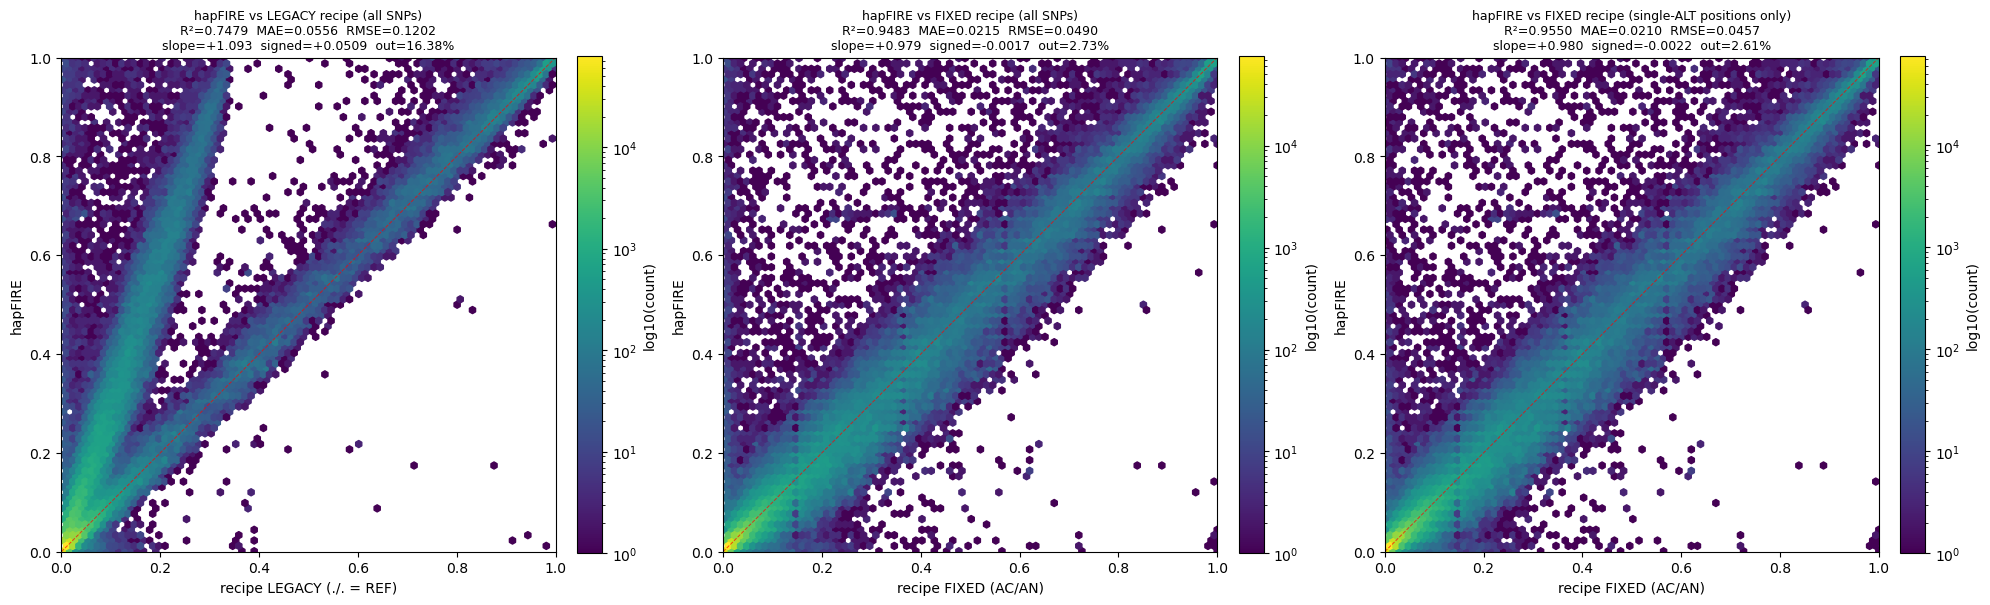

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))
hexbin(axes[0], recipe_legacy, hf_af, 'recipe LEGACY (./. = REF)', 'hapFIRE',
       'hapFIRE vs LEGACY recipe (all SNPs)')
if recipe_fixed is not None:
    hexbin(axes[1], recipe_fixed, hf_af, 'recipe FIXED (AC/AN)', 'hapFIRE',
           'hapFIRE vs FIXED recipe (all SNPs)')
    hexbin(axes[2], recipe_fixed, hf_af, 'recipe FIXED (AC/AN)', 'hapFIRE',
           'hapFIRE vs FIXED recipe (single-ALT positions only)',
           mask=single_alt_mask)
else:
    axes[1].text(0.5, 0.5, 'cn_var_called not yet built', ha='center', va='center')
    axes[2].axis('off')
plt.tight_layout()
plt.savefig('plots/AF_TRUTH_VS_ESTIMATE_v3qc_v2_recipe_fix.png', dpi=130, bbox_inches='tight')
plt.show()

## Per-config scatter grid (vs FIXED recipe + vs hapFIRE)

Row 0 is hapFIRE itself for reference. Subsequent rows are each cactus_em config.

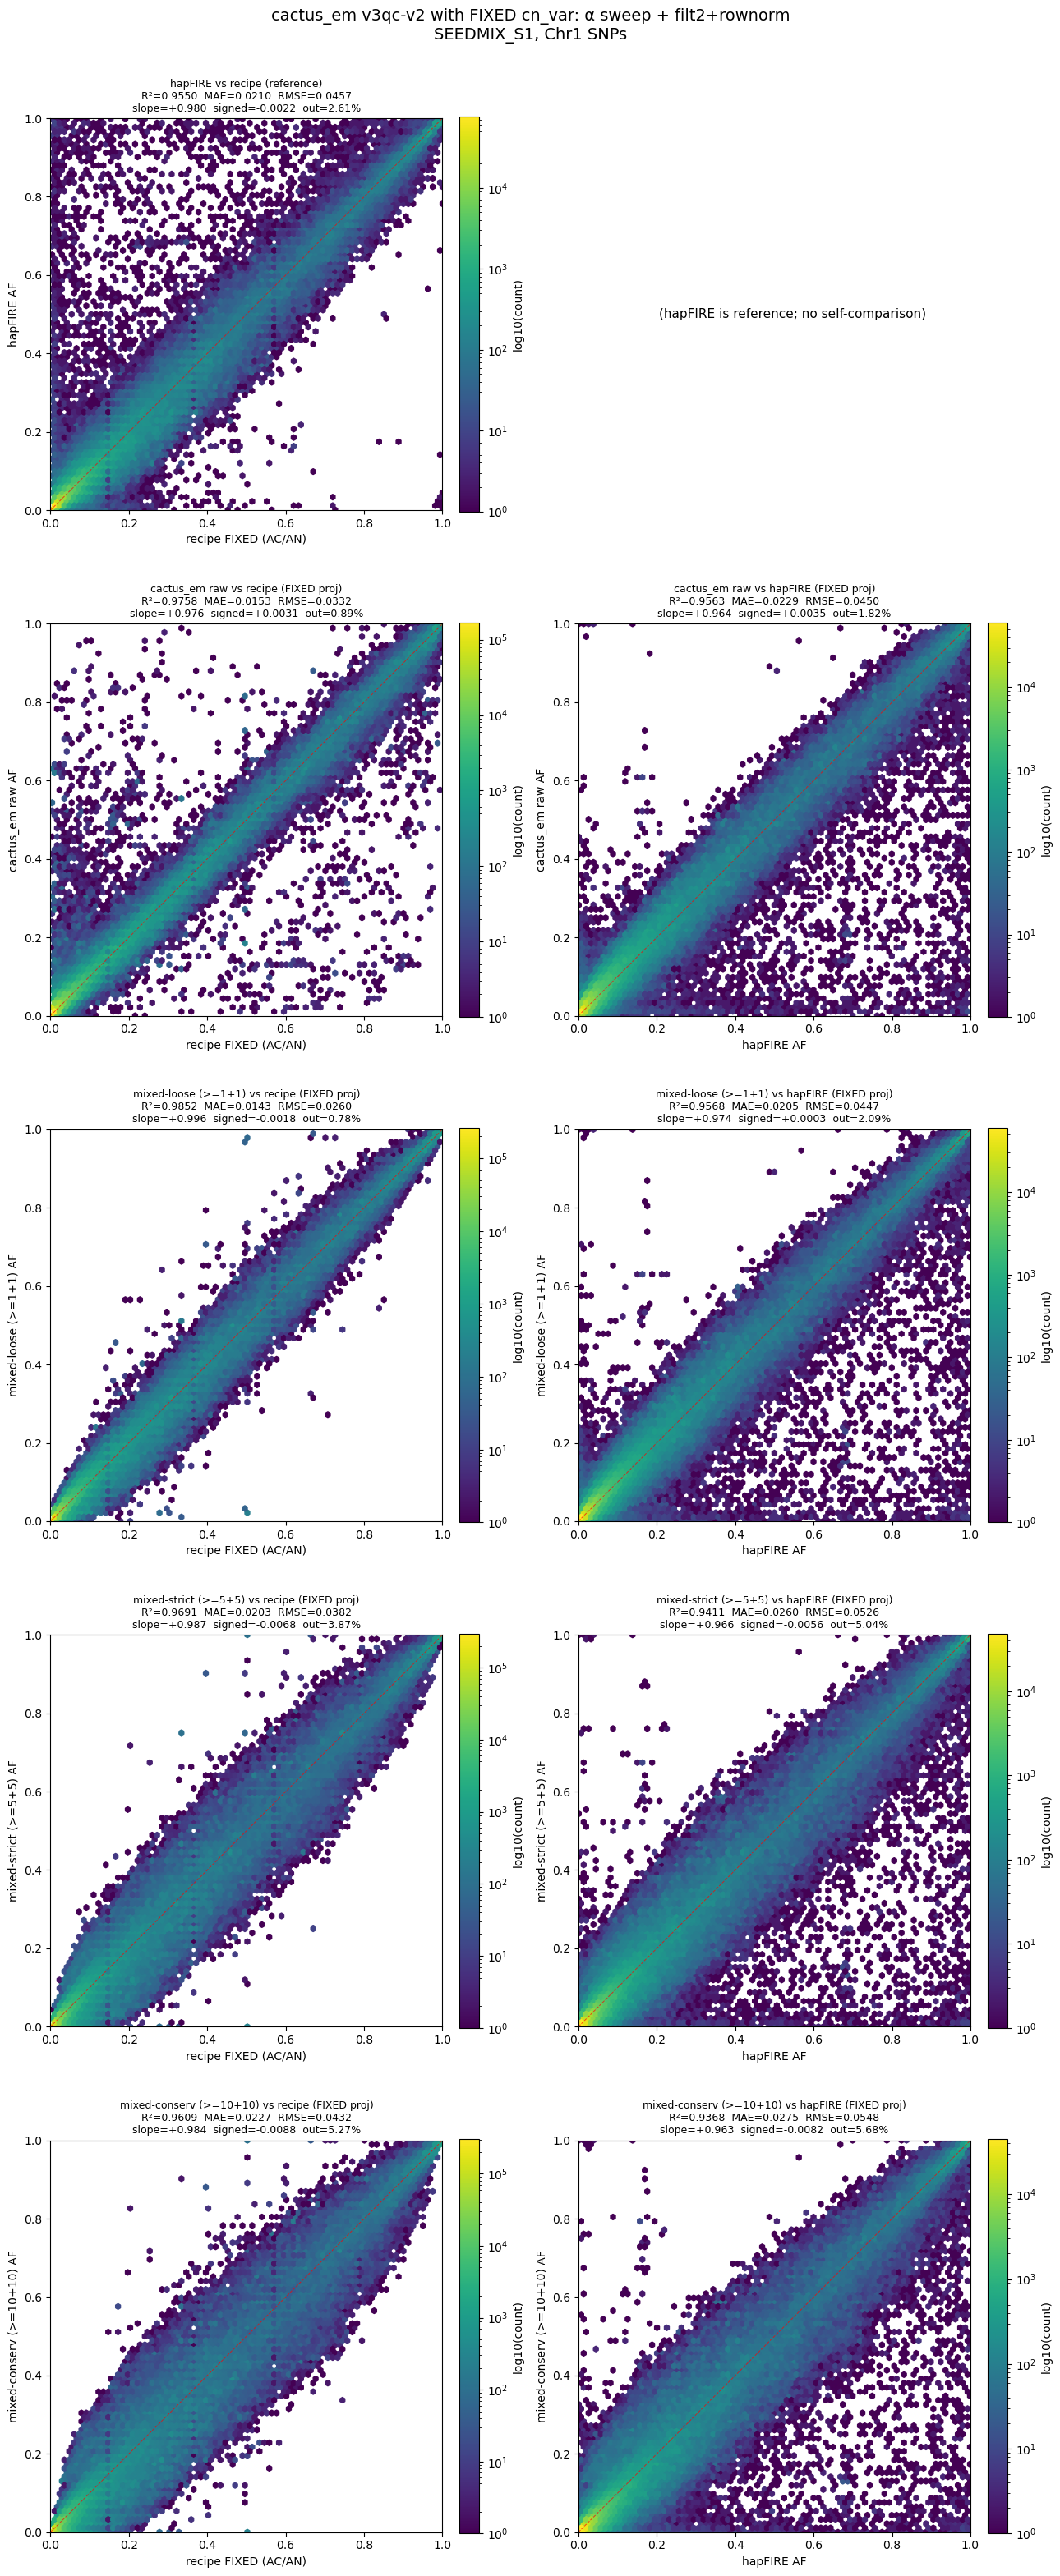

In [6]:
ref_truth = recipe_fixed if recipe_fixed is not None else recipe_legacy
ref_label = 'recipe FIXED (AC/AN)' if recipe_fixed is not None else 'recipe LEGACY'

method_names = list(cem_af.keys())
n_rows = 1 + len(method_names)
fig, axes = plt.subplots(n_rows, 2, figsize=(13, 6.3 * n_rows))
if n_rows == 1:
    axes = np.atleast_2d(axes)

hexbin(axes[0, 0], ref_truth, hf_af, ref_label, 'hapFIRE AF',
       'hapFIRE vs recipe (reference)', mask=single_alt_mask)
axes[0, 1].axis('off')
axes[0, 1].text(0.5, 0.5, '(hapFIRE is reference; no self-comparison)',
                ha='center', va='center', fontsize=11, transform=axes[0, 1].transAxes)

for i, name in enumerate(method_names, start=1):
    cem = cem_af[name]
    src_tag = 'FIXED proj' if ('FIXED' in config_source.get(name, '') or 'NEW' in config_source.get(name, '')) else 'legacy proj'
    hexbin(axes[i, 0], ref_truth, cem, ref_label, f'{name} AF',
           f'{name} vs recipe ({src_tag})')
    hexbin(axes[i, 1], hf_af,    cem, 'hapFIRE AF',                f'{name} AF',
           f'{name} vs hapFIRE ({src_tag})', mask=single_alt_mask)

fig.suptitle('cactus_em v3qc-v2 with FIXED cn_var: α sweep + filt2+rownorm\n'
             'SEEDMIX_S1, Chr1 SNPs', y=0.999, fontsize=14)
plt.tight_layout()
plt.savefig('plots/AF_TRUTH_VS_ESTIMATE_v3qc_v2_kfalpha_sweep.png', dpi=130, bbox_inches='tight')
plt.show()

## Summary table + Pareto

In [7]:
rows = []
m = metrics(ref_truth, hf_af, single_alt_mask)
if m is not None:
    rows.append({'method': 'hapFIRE', 'reference': ref_label, **{k:m[k] for k in ['n','r2','mae','rmse','slope','signed','out']}})
for name in method_names:
    cem = cem_af[name]
    for ref_name, ref_v, mk in [(ref_label, ref_truth, None), ('hapFIRE', hf_af, single_alt_mask)]:
        m = metrics(ref_v, cem, mk)
        if m is not None:
            rows.append({'method': name, 'reference': ref_name, **{k:m[k] for k in ['n','r2','mae','rmse','slope','signed','out']}})
tbl = pd.DataFrame(rows)
for col in ['r2','mae','rmse','slope','signed']:
    tbl[col] = tbl[col].map(lambda x: f'{x:.4f}')
tbl['out'] = tbl['out'].map(lambda x: f'{100*x:.2f}%')
print(tbl.to_string(index=False))

                 method            reference       n     r2    mae   rmse  slope  signed   out
                hapFIRE recipe FIXED (AC/AN)  512392 0.9550 0.0210 0.0457 0.9802 -0.0022 2.61%
          cactus_em raw recipe FIXED (AC/AN) 1019835 0.9758 0.0153 0.0332 0.9761  0.0031 0.89%
          cactus_em raw              hapFIRE  512392 0.9563 0.0229 0.0450 0.9644  0.0035 1.82%
    mixed-loose (>=1+1) recipe FIXED (AC/AN) 1019835 0.9852 0.0143 0.0260 0.9956 -0.0018 0.78%
    mixed-loose (>=1+1)              hapFIRE  512392 0.9568 0.0205 0.0447 0.9744  0.0003 2.09%
   mixed-strict (>=5+5) recipe FIXED (AC/AN) 1019835 0.9691 0.0203 0.0382 0.9874 -0.0068 3.87%
   mixed-strict (>=5+5)              hapFIRE  512392 0.9411 0.0260 0.0526 0.9661 -0.0056 5.04%
mixed-conserv (>=10+10) recipe FIXED (AC/AN) 1019835 0.9609 0.0227 0.0432 0.9836 -0.0088 5.27%
mixed-conserv (>=10+10)              hapFIRE  512392 0.9368 0.0275 0.0548 0.9633 -0.0082 5.68%


                 config   h_bias  mae_vs_recipe_FIXED  mae_vs_hapFIRE
          cactus_em raw 190.1508               0.0153          0.0229
    mixed-loose (>=1+1)   1.1977               0.0143          0.0205
   mixed-strict (>=5+5)   0.6872               0.0203          0.0260
mixed-conserv (>=10+10)   0.5014               0.0227          0.0275


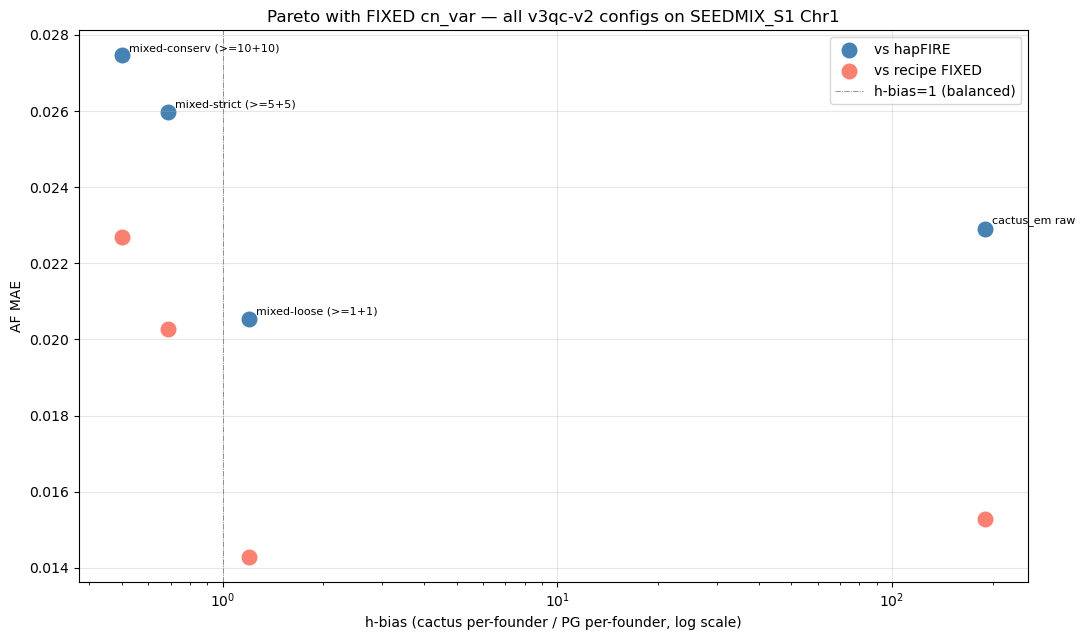

In [8]:
import json
with open(ROOT / 'data/founder_split_cactus_pg.json') as f:
    split = json.load(f)
cactus_set = set(map(str, split['cactus']))
pg_set = set(map(str, split['PG']))

def h_bias_from_npz(npz_path):
    d = np.load(npz_path, allow_pickle=True)
    founders = list(d['founders'])
    h = d['Chr1']
    is_c = np.array([f in cactus_set for f in founders])
    is_p = np.array([f in pg_set for f in founders])
    pf_c = h[is_c].sum() / is_c.sum()
    pf_p = h[is_p].sum() / is_p.sum()
    return pf_c / pf_p if pf_p > 0 else np.nan

summary = []
for name in method_names:
    cand = config_source.get(name)
    if cand is None:
        continue
    npz = SCRATCH / cand / 'SEEDMIX_S1.h_per_chrom.npz'
    if not npz.exists():
        continue
    bias = h_bias_from_npz(npz)
    cem = cem_af[name]
    m_rec = metrics(ref_truth, cem)
    m_hf  = metrics(hf_af, cem, single_alt_mask)
    summary.append({
        'config': name, 'h_bias': bias,
        'mae_vs_recipe_FIXED': m_rec['mae'] if m_rec else np.nan,
        'mae_vs_hapFIRE':       m_hf['mae'] if m_hf else np.nan,
    })
summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False, float_format='%.4f'))

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.scatter(summary_df['h_bias'], summary_df['mae_vs_hapFIRE'], s=110, c='steelblue', label='vs hapFIRE')
ax.scatter(summary_df['h_bias'], summary_df['mae_vs_recipe_FIXED'], s=110, c='salmon', label='vs recipe FIXED')
for _, r in summary_df.iterrows():
    ax.annotate(r['config'], (r['h_bias'], r['mae_vs_hapFIRE']),
                fontsize=8, xytext=(5, 3), textcoords='offset points')
ax.axvline(1.0, c='gray', ls='-.', lw=0.6, label='h-bias=1 (balanced)')
ax.set_xscale('log')
ax.set_xlabel('h-bias (cactus per-founder / PG per-founder, log scale)')
ax.set_ylabel('AF MAE')
ax.set_title('Pareto with FIXED cn_var — all v3qc-v2 configs on SEEDMIX_S1 Chr1')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/AF_TRUTH_VS_ESTIMATE_v3qc_v2_pareto.png', dpi=130, bbox_inches='tight')
plt.show()